#Assignment 1

Max collaborators = 3

There is a bit of handholding. If you still do not understand something, feel free to reach out to your lab faculties. Good luck.

In [ ]:
# COLLABORATOR_1_NAME = ""
# COLLABORATOR_1_ID = ""

# Part 1 [15 Marks]

In this part, you will work with point processing, HE, AHE, and CLAHE.

In [ ]:
import numpy as np
from skimage import io, color, exposure
import matplotlib.pyplot as plt
### If you need other dependencies import here -
from skimage import img_as_float

#ignore warning
import warnings
warnings.filterwarnings("ignore")
### Code ends

In [ ]:
### If you need helper functions defined, define here -

### Code ends

## Task 1 - Basic Image Operation

Import any photograph taken by you (RGB) (`sample_1.jpeg`/`sample_1.jpg`) as a numpy array, save it in the varaible `I`.

A picture taken from your phone of any scenary/streets/building is better.

Remember - your image name MUST be `sample_1.jpeg`/`sample_1.jpg`.

Make sure the height and the width of the image is **smaller than 1000 pixels**.

In [ ]:
I = io.imread('sample_1.jpg')  # Replace None with appropriate import function call


# find the height and the width of the image
H = I.shape[0]  # should contain height
W = I.shape[1]  # should contain width
print("Height is", H)
print("Width is", W)

Height is 873
Width is 640


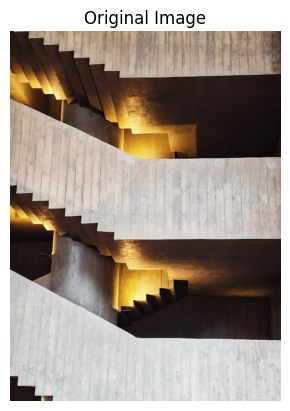

In [ ]:
I = img_as_float(I)  # Replace none and normalize the image so that the pixel values of each channel are between 0 and 1

### Write a code to display the image -
plt.imshow(I)
plt.axis('off')
plt.title('Original Image')
plt.show()
### Code ends

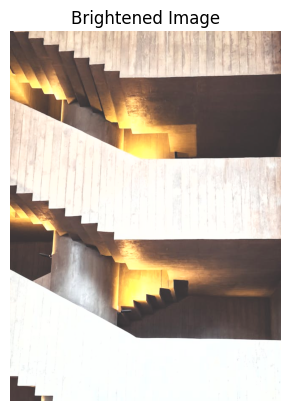

In [ ]:
# Increase the brightness of the image without changing the contrast.
# Save the resulting image in I_bright.
### Hint - You have to convert to LAB first
I_lab = color.rgb2lab(I)
I_lab[:, :, 0] = np.clip(I_lab[:, :, 0] + 20, 0, 100)  # Increase L channel
I_bright = color.lab2rgb(I_lab)

### Write a code to display the I_bright -
plt.imshow(I_bright)
plt.axis('off')
plt.title('Brightened Image')
plt.show()
### Code ends

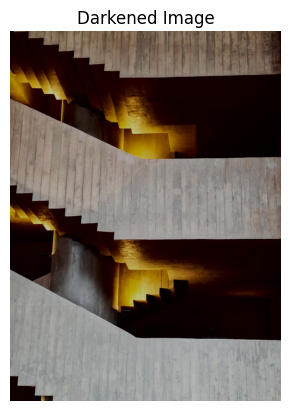

In [ ]:
# Decrease the brightness of the image without changing the contrast.
# Save the resulting image in I_dark.
I_lab = color.rgb2lab(I)
I_lab[:, :, 0] = np.clip(I_lab[:, :, 0] - 20, 0, 100)  # Decrease L channel
I_dark = color.lab2rgb(I_lab)

### Write a code to display the I_dark -
plt.imshow(I_dark)
plt.axis('off')
plt.title('Darkened Image')
plt.show()
### Code ends

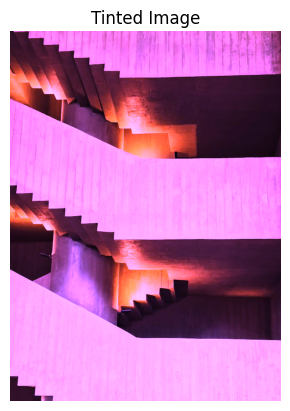

In [ ]:
# Multiply the three channels of image I with three DIFFERENT numbers between 0.3 and 3
# Save the resulting image in I_tint and display it.
# The resulting image should have some color shift
I_tint = I.copy()
I_tint[:, :, 0] = np.clip(I_tint[:, :, 0] * 1.5, 0, 1)  # Red channel
I_tint[:, :, 1] = np.clip(I_tint[:, :, 1] * 0.8, 0, 1)  # Green channel
I_tint[:, :, 2] = np.clip(I_tint[:, :, 2] * 2.0, 0, 1)  # Blue channel

### Write a code to display the I_tint -
plt.imshow(I_tint)
plt.axis('off')
plt.title('Tinted Image')
plt.show()
### Code ends

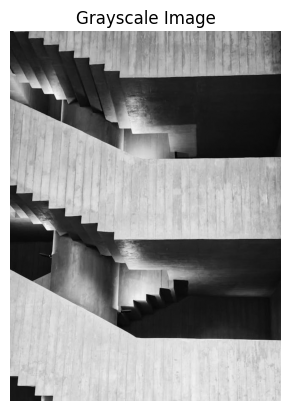

In [ ]:
# Convert the image into a grayscale image.
# Save it to I_gray and display it
I_gray = color.rgb2gray(I)

### Write a code to display the I_gray -
plt.imshow(I_gray, cmap='gray')
plt.axis('off')
plt.title('Grayscale Image')
plt.show()
### Code ends

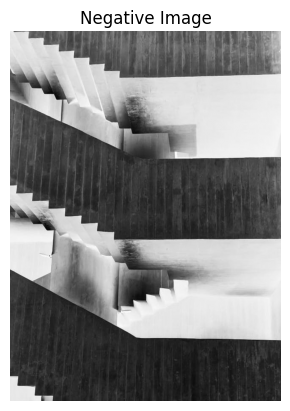

In [ ]:
# Display the negative of the grayscale image
I_neg = 1 - I_gray

### Write a code to display the I_neg -
plt.imshow(I_neg, cmap='gray')
plt.axis('off')
plt.title('Negative Image')
plt.show()
### Code ends

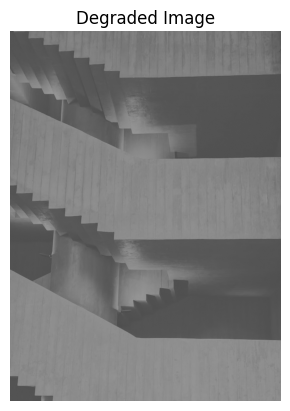

In [ ]:
# This cell will artificially degrade your grayscale image by reducing contrast
# The max pixel value is mapped to 0.6 and the min pixel value is mapped to 0.3
I_degraded = exposure.rescale_intensity(I_gray, in_range=(0, 1), out_range=(0.3, 0.6))

# Try to understand what is going on
# You will need to use this concept later on

### Write a code to display the I_degraded -
plt.imshow(I_degraded, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('Degraded Image')
plt.show()
# If you use plt.imshow(), set vmin = 0, vmax = 1

### Code ends

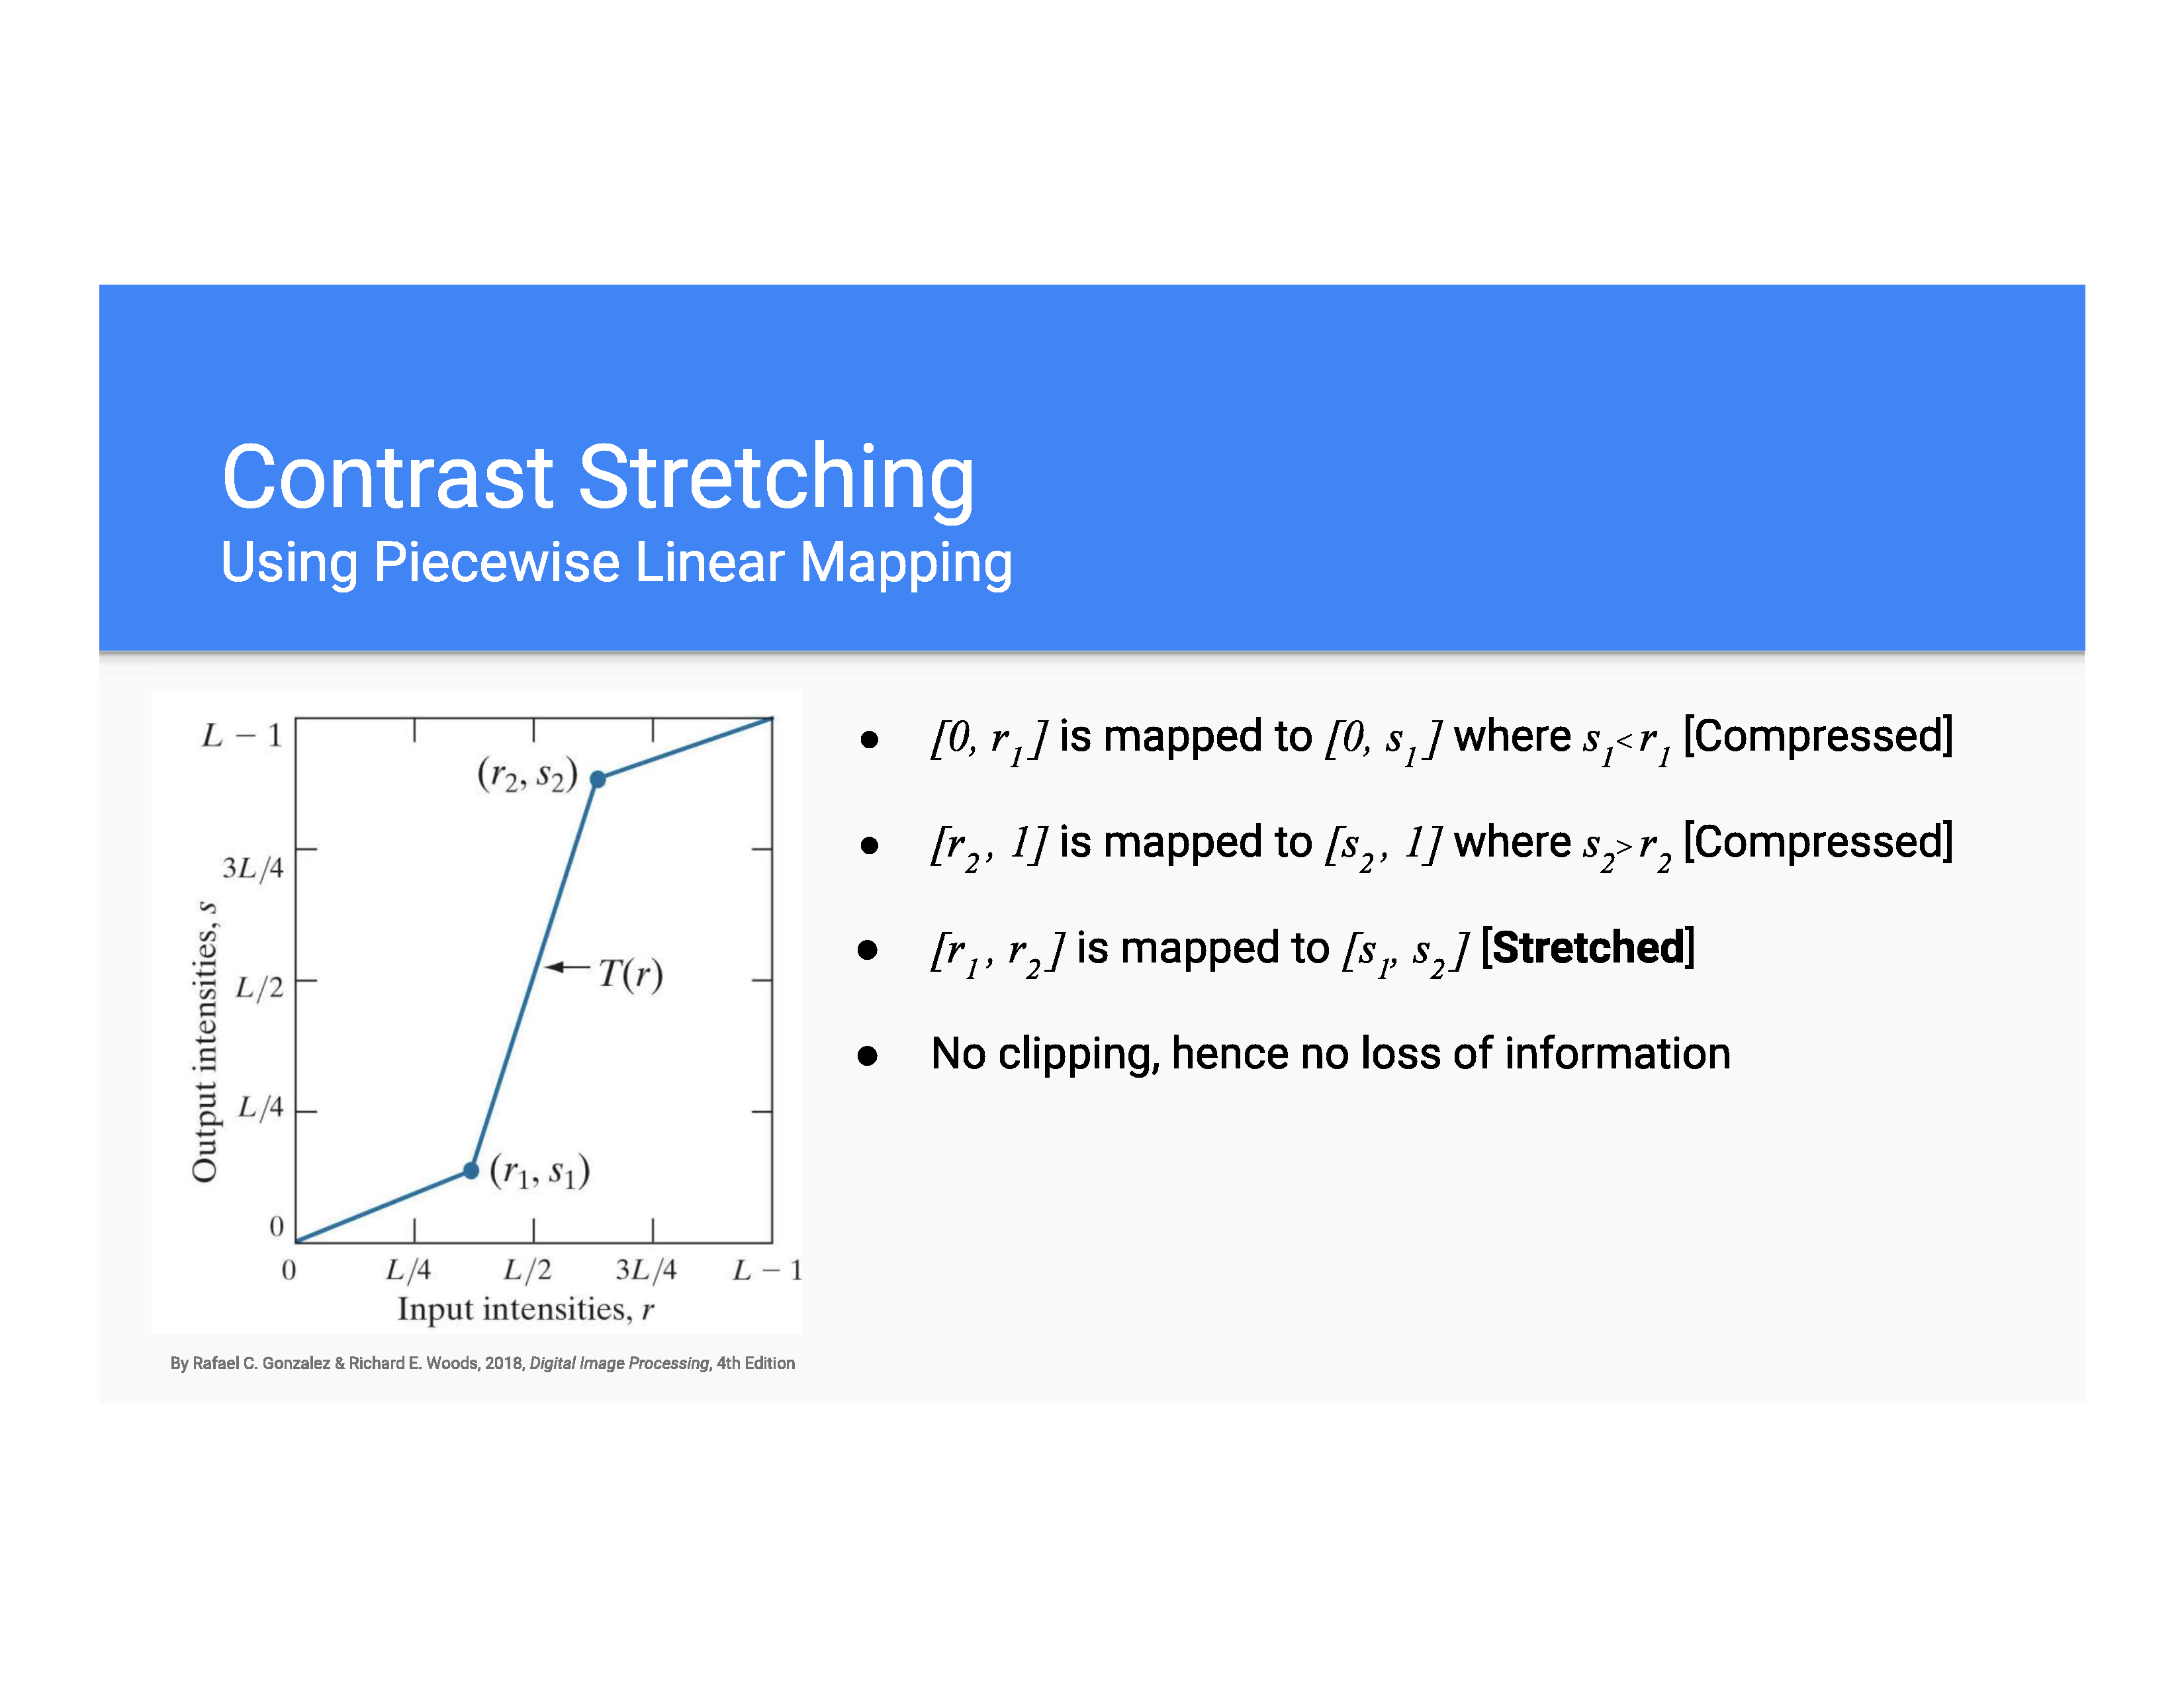

In [ ]:
# Complete the following function to perform Piecewise Linear Contrast stretching
# That is, implement the map shown in the picture above

# Assume both input and output images are normalized between 0 and 1

def piecewise_contrast_stretch(I, r1, r2, s1, s2):
    # Write your code here
    I_stretched = np.copy(I).astype(float)

    #For values below r1, map linearly from [0, r1] to [0, s1]
    mask1 = I < r1
    I_stretched[mask1] = (s1 / r1) * I[mask1]

    #For values between r1 and r2, map linearly from [r1, r2] to [ s1, s2]
    mask2 = (I >= r1) & (I <= r2)
    I_stretched[mask2] = ((s2 - s1) / (r2 - r1)) * (I[mask2] - r1) + s1

    #For values above r2, map linearly from [r2, 1] to [s2, 1]
    mask3 = I > r2
    I_stretched[mask3] = ((1 - s2) / (1 - r2)) * (I[mask3] - r2) + s2

    return I_stretched

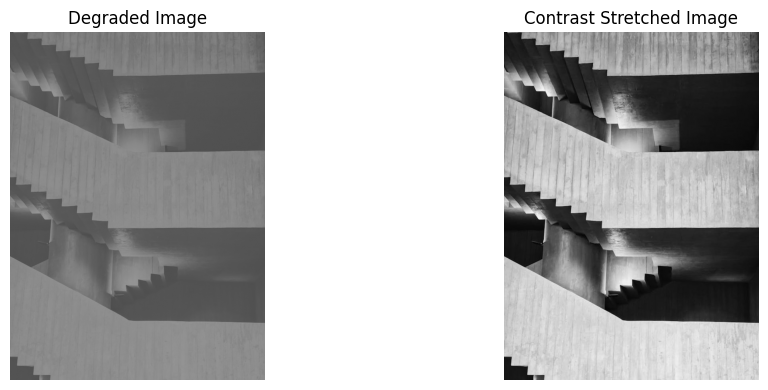

In [ ]:
# To test your implementation, contrast strech the degraded image I_degrade to fix it
r1 = 0.3  # minimum value in degraded image (adjust based on histogram)
r2 = 0.6  # maximum value in degraded image (adjust based on histogram)
s1 = 0  # map to minimum (0)
s2 = 1  # map to maximum (1)
I_stretched = piecewise_contrast_stretch(I_degraded, r1, r2, s1, s2)

### Write a code to display the I_stretched -
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(I_degraded, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('Degraded Image')

plt.subplot(1, 2, 2)
plt.imshow(I_stretched, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title('Contrast Stretched Image')
plt.tight_layout()
plt.show()
### Code ends

## Task 2 - Histogram and Equalization

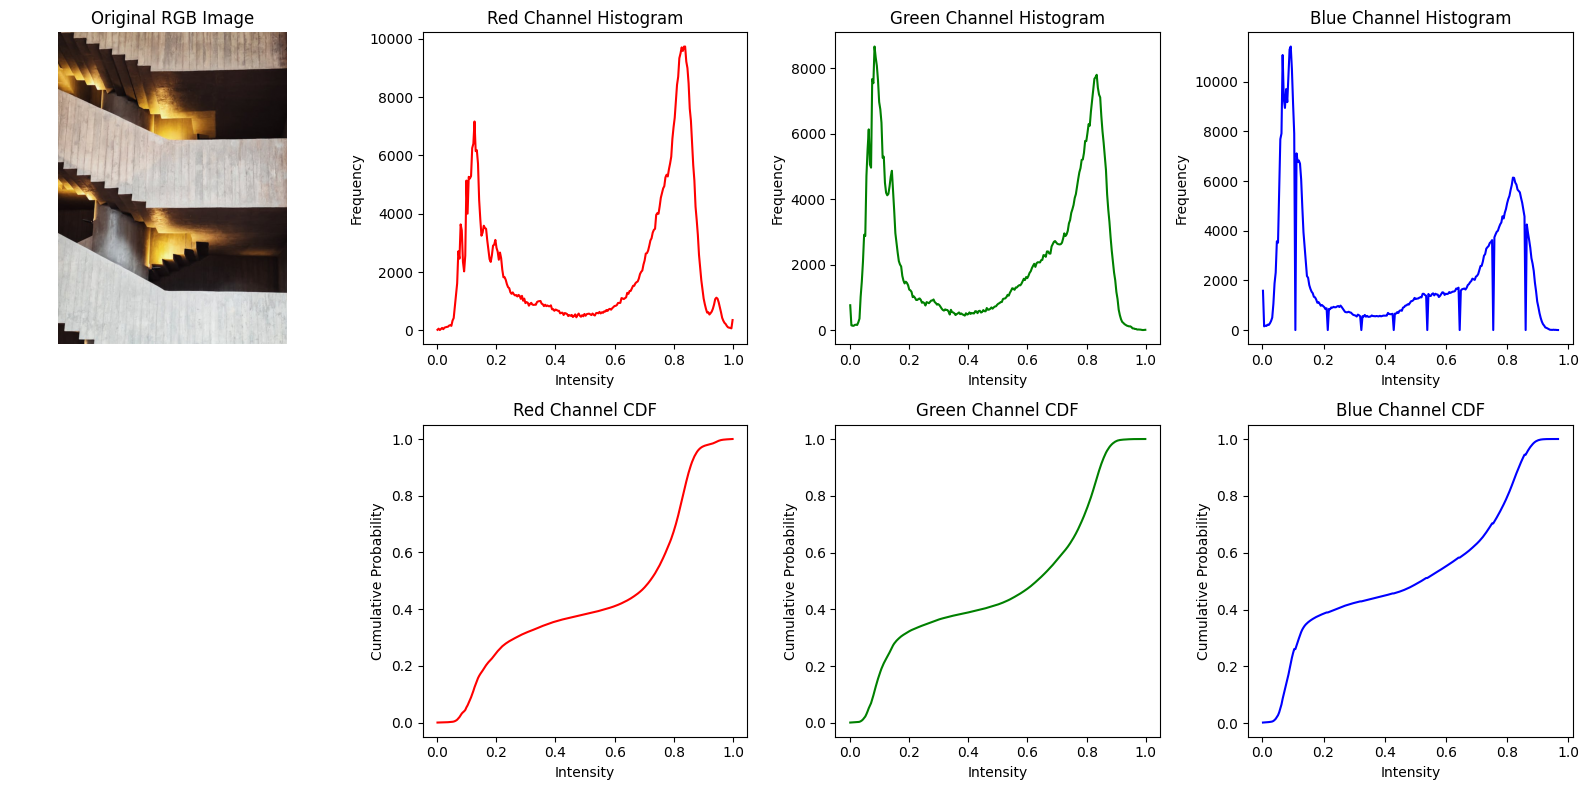

In [ ]:
# Plot the image and its histogram + cdf of the original image I
# Note that it is a color image, so it will have three different histograms

### Begin solution
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

#Display original image
axes[0, 0].imshow(I)
axes[0, 0].axis('off')
axes[0, 0].set_title('Original RGB Image')
axes[1, 0].axis('off')

colors = ['red', 'green', 'blue']
channel_names = ['Red', 'Green', 'Blue']

# Plot histograms and CDFs for each channel
for idx, (ch_color, name) in enumerate(zip(colors, channel_names)):
    channel = I[:, :, idx]
    hist, bins = exposure.histogram(channel, nbins=256)
    cdf = np.cumsum(hist) / np.sum(hist)

    #Histogram
    axes[0, idx+1].plot(bins, hist, color=ch_color)
    axes[0, idx+1].set_title(f'{name} Channel Histogram')
    axes[0, idx+1].set_xlabel('Intensity')
    axes[0, idx+1].set_ylabel('Frequency')

    #cdf
    axes[1, idx+1].plot(bins, cdf, color=ch_color)
    axes[1, idx+1].set_title(f'{name} Channel CDF')
    axes[1, idx+1].set_xlabel('Intensity')
    axes[1, idx+1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()
### End solution

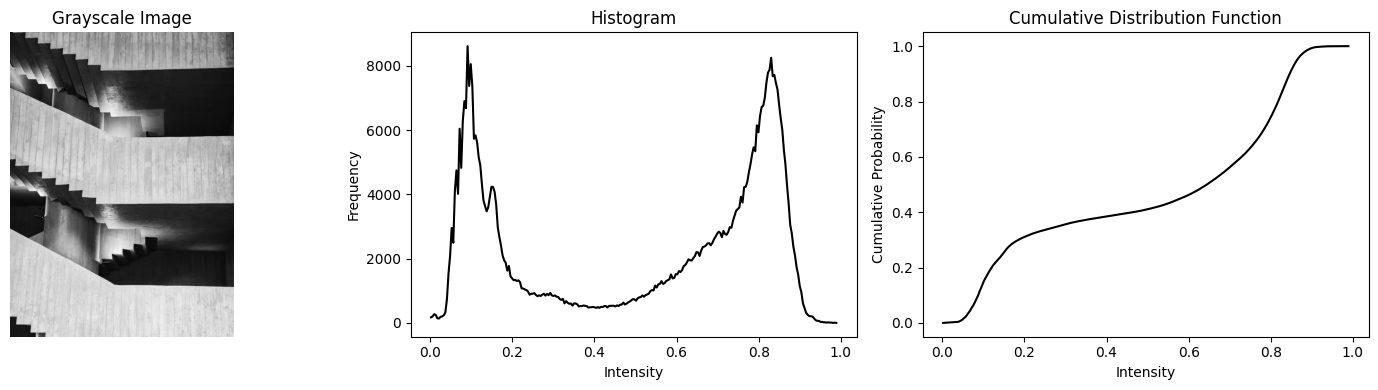

In [ ]:
# Plot the grayscale image, I_gray, and its histogram + cdf

### Begin solution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Display Grayscale Image
axes[0].imshow(I_gray, cmap='gray')
axes[0].axis('off')
axes[0].set_title('Grayscale Image')

#Histogram
hist, bins = exposure.histogram(I_gray, nbins=256)
axes[1].plot(bins, hist, color='black')
axes[1].set_title('Histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Frequency')

#cdf
cdf = np.cumsum(hist) / np.sum(hist)
axes[2].plot(bins, cdf, color='black')
axes[2].set_title('Cumulative Distribution Function')
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()
### End solution

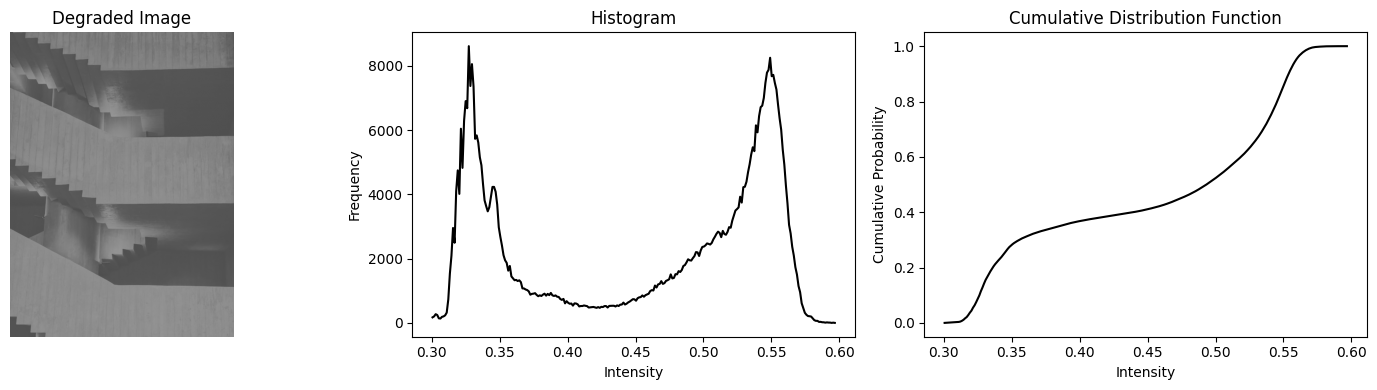

In [ ]:
# Plot the degraded image, I_degraded, and its histogram + cdf

### Begin solution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Display degraded image
# If you use plt.imshow(), set vmin = 0, vmax = 1 for the degraded image
axes[0].imshow(I_degraded, cmap='gray', vmin=0, vmax=1)
axes[0].axis('off')
axes[0].set_title('Degraded Image')

# Histogram
hist, bins = exposure.histogram(I_degraded, nbins=256)
axes[1].plot(bins, hist, color='black')
axes[1].set_title('Histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Frequency')

# cdf
cdf = np.cumsum(hist) / np.sum(hist)
axes[2].plot(bins, cdf, color='black')
axes[2].set_title('Cumulative Distribution Function')
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()
### End solution

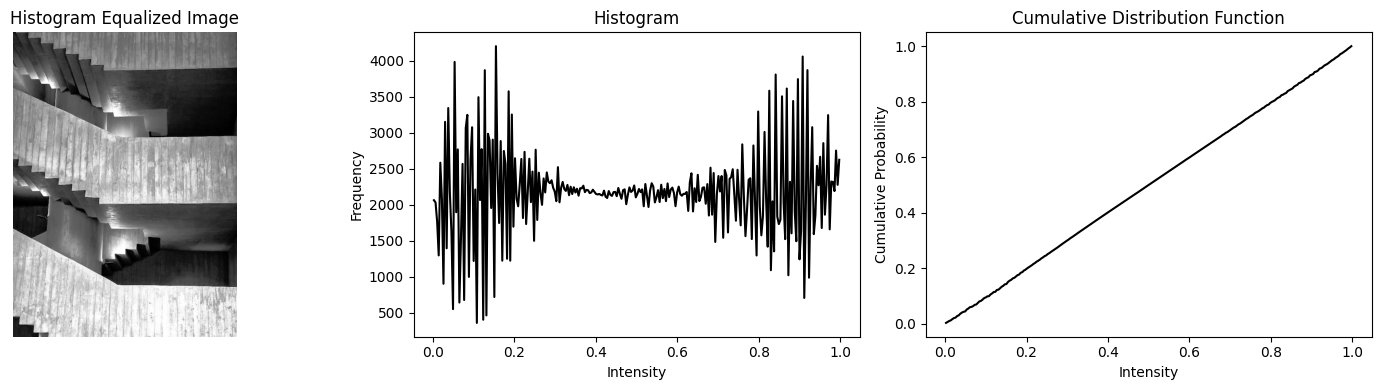

In [ ]:
# Equalize the histogram of the degraded image I_degraded
# Save the result in I_recon_gray
I_recon_gray = exposure.equalize_hist(I_degraded)

### Write a code to display the I_recon_gray along with its histogram + CDF -
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Display equalized image
axes[0].imshow(I_recon_gray, cmap='gray')
axes[0].axis('off')
axes[0].set_title('Histogram Equalized Image')

#Histogram
hist, bins = exposure.histogram(I_recon_gray, nbins=256)
axes[1].plot(bins, hist, color='black')
axes[1].set_title('Histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Frequency')

#cdf
cdf = np.cumsum(hist) / np.sum(hist)
axes[2].plot(bins, cdf, color='black')
axes[2].set_title('Cumulative Distribution Function')
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()
### Code ends

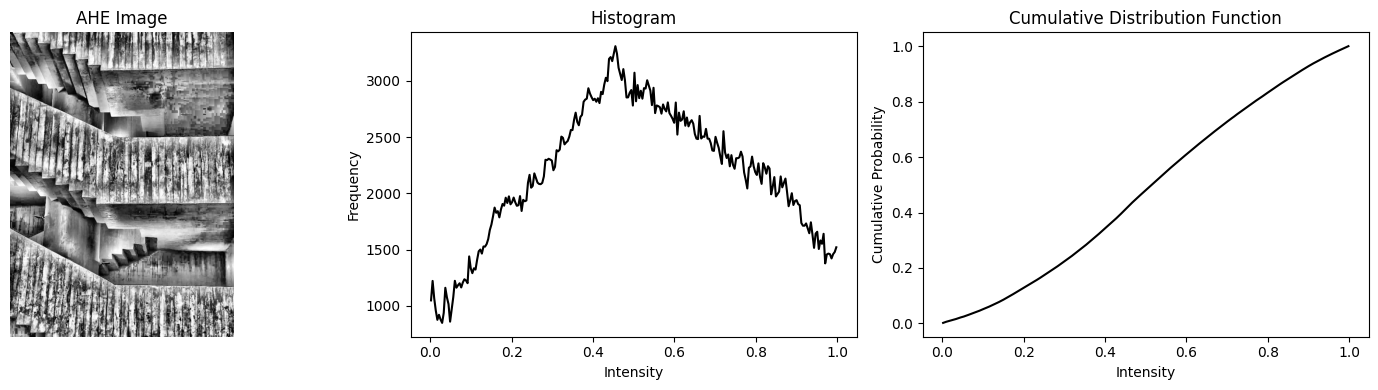

In [ ]:
# Equalize the histogram of the degraded image I_degraded using AHE
# Save the result in I_recon_gray_2
I_recon_gray_2 = exposure.equalize_adapthist(I_degraded, kernel_size=(64, 64), clip_limit=0)

### Write a code to display the I_recon_gray_2 along with its histogram + CDF -
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Display AHE image
axes[0].imshow(I_recon_gray_2, cmap='gray')
axes[0].axis('off')
axes[0].set_title('AHE Image')

# Histogram
hist, bins = exposure.histogram(I_recon_gray_2, nbins=256)
axes[1].plot(bins, hist, color='black')
axes[1].set_title('Histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Frequency')

# cdf
cdf = np.cumsum(hist) / np.sum(hist)
axes[2].plot(bins, cdf, color='black')
axes[2].set_title('Cumulative Distribution Function')
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()
### Code ends

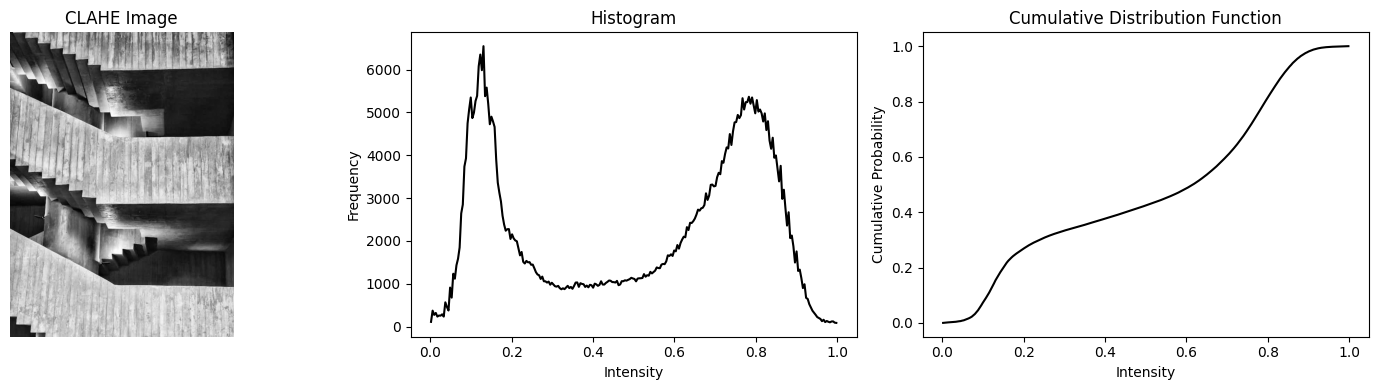

In [ ]:
# Equalize the histogram of the degraded image I_degraded using CLAHE
# Save the result in I_recon_gray_3
I_recon_gray_3 = exposure.equalize_adapthist(I_degraded, kernel_size=(64, 64), clip_limit=0.01)

### Write a code to display the I_recon_gray_3 along with its histogram + CDF -
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Display CLAHE image
axes[0].imshow(I_recon_gray_3, cmap='gray')
axes[0].axis('off')
axes[0].set_title('CLAHE Image')

# Histogram
hist, bins = exposure.histogram(I_recon_gray_3, nbins=256)
axes[1].plot(bins, hist, color='black')
axes[1].set_title('Histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Frequency')

# cdf
cdf = np.cumsum(hist) / np.sum(hist)
axes[2].plot(bins, cdf, color='black')
axes[2].set_title('Cumulative Distribution Function')
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()
### Code ends

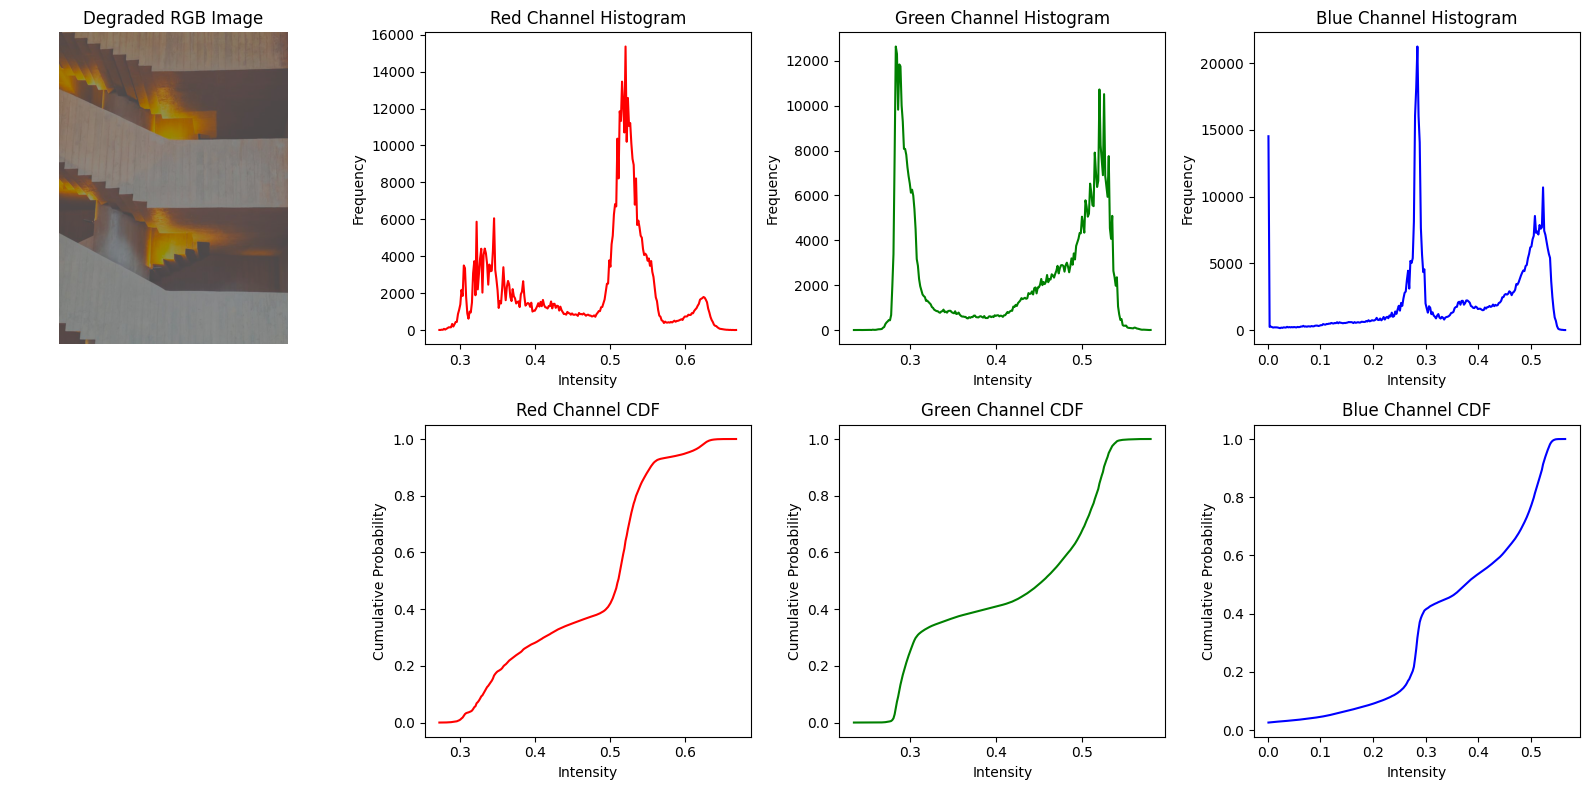

In [ ]:
# Artificially degrade the original **RGB image** by reducing it contrast
# You can do so by recaling the values of the L channel (in LAB color space)
# You need to normalize the L channel first
# Then concentrate the intensities in a narrow range, say between 0.3 and 0.6.
# Save the image as I_rgb_degraded and display it

# Convert to LAB color space
I_lab_rgb = color.rgb2lab(I)

# Normalize L channel to [0, 1]
L_normalized = I_lab_rgb[:, :, 0] / 100.0

# Concentrate intensities in narrow range [0.3, 0.6]
L_degraded = L_normalized * 0.3 + 0.3

# Convert back to [0, 100] range for L channel
I_lab_rgb[:, :, 0] = L_degraded * 100.0

# Convert back to RGB
I_rgb_degraded = color.lab2rgb(I_lab_rgb)

### Write a code to display the I_rgb_degraded along with its RGB histogram -
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Display degraded RGB image
# If you use plt.imshow(), set vmin = 0, vmax = 1
axes[0, 0].imshow(I_rgb_degraded, vmin=0, vmax=1)
axes[0, 0].axis('off')
axes[0, 0].set_title('Degraded RGB Image')
axes[1, 0].axis('off')

colors = ['red', 'green', 'blue']
channel_names = ['Red', 'Green', 'Blue']

# Plot histograms for each channel
for idx, (ch_color, name) in enumerate(zip(colors, channel_names)):
    channel = I_rgb_degraded[:, :, idx]
    hist, bins = exposure.histogram(channel, nbins=256)
    cdf = np.cumsum(hist) / np.sum(hist)

    # Histogram
    axes[0, idx+1].plot(bins, hist, color=ch_color)
    axes[0, idx+1].set_title(f'{name} Channel Histogram')
    axes[0, idx+1].set_xlabel('Intensity')
    axes[0, idx+1].set_ylabel('Frequency')

    # cdf
    axes[1, idx+1].plot(bins, cdf, color=ch_color)
    axes[1, idx+1].set_title(f'{name} Channel CDF')
    axes[1, idx+1].set_xlabel('Intensity')
    axes[1, idx+1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()
### Code ends

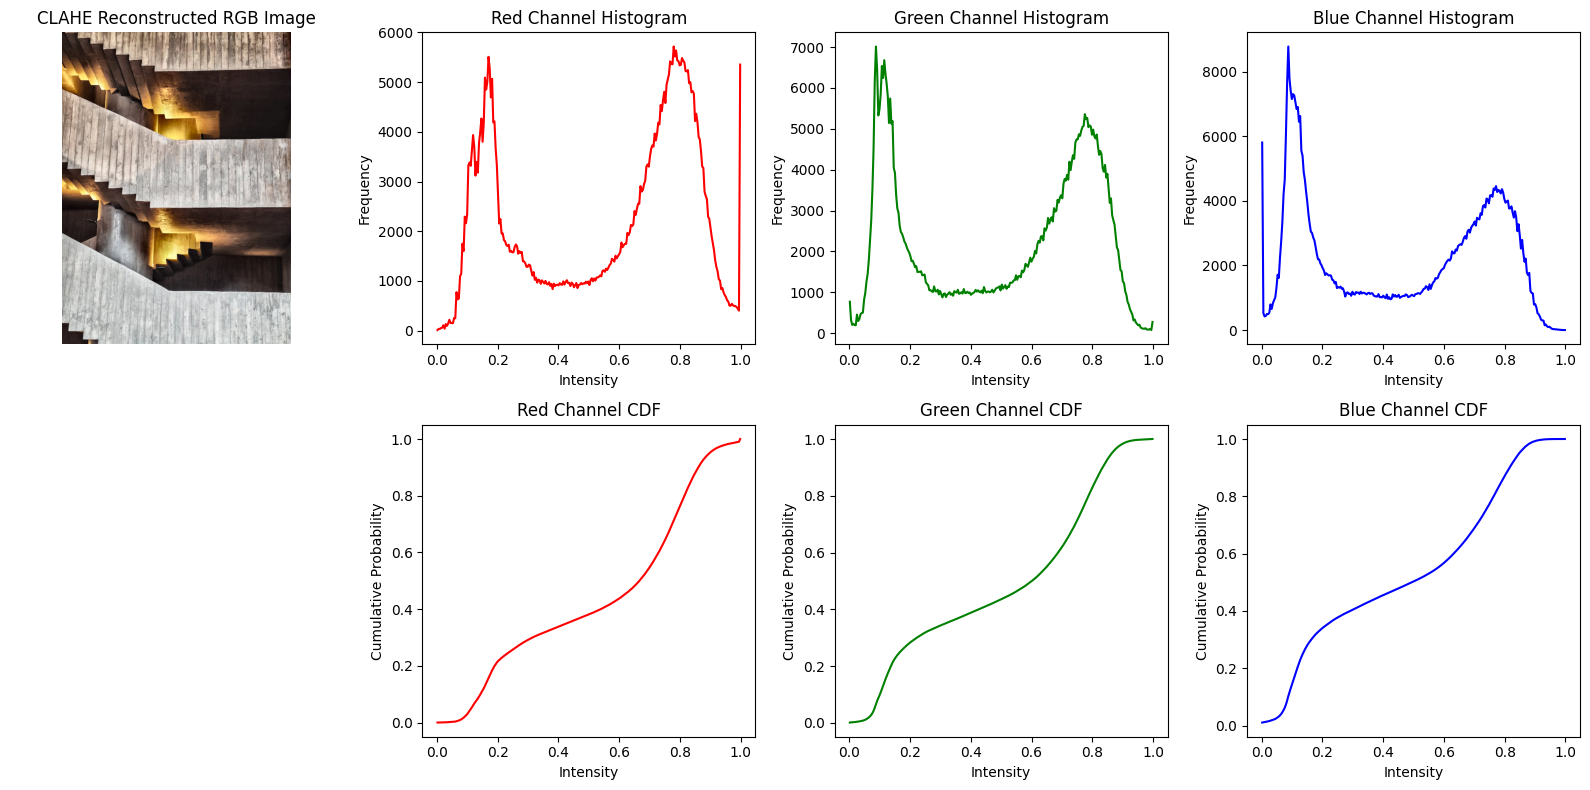

In [ ]:
# Equalize the histogram of the degraded color image I_rgb_degraded using CLAHE
# Save the result in I_recon_color, display the image along with its histogram
# HINT: You have to convert to LAB first

# Convert to LAB
I_lab_degraded = color.rgb2lab(I_rgb_degraded)

# Apply CLAHE on L channel
L_channel = I_lab_degraded[:, :, 0] / 100.0  # Normalize to [0, 1]
L_clahe = exposure.equalize_adapthist(L_channel, kernel_size=(64, 64), clip_limit=0.01)
I_lab_degraded[:, :, 0] = L_clahe * 100.0  # Convert back to [0, 100]

# Convert back to RGB
I_recon_color = color.lab2rgb(I_lab_degraded)

### Write a code to display the I_recon_color along with its RGB histogram -
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Display reconstructed RGB image
axes[0, 0].imshow(I_recon_color)
axes[0, 0].axis('off')
axes[0, 0].set_title('CLAHE Reconstructed RGB Image')
axes[1, 0].axis('off')

colors = ['red', 'green', 'blue']
channel_names = ['Red', 'Green', 'Blue']

# Plot histograms for each channel
for idx, (ch_color, name) in enumerate(zip(colors, channel_names)):
    channel = I_recon_color[:, :, idx]
    hist, bins = exposure.histogram(channel, nbins=256)
    cdf = np.cumsum(hist) / np.sum(hist)

    # Histogram
    axes[0, idx+1].plot(bins, hist, color=ch_color)
    axes[0, idx+1].set_title(f'{name} Channel Histogram')
    axes[0, idx+1].set_xlabel('Intensity')
    axes[0, idx+1].set_ylabel('Frequency')

    # cdf
    axes[1, idx+1].plot(bins, cdf, color=ch_color)
    axes[1, idx+1].set_title(f'{name} Channel CDF')
    axes[1, idx+1].set_xlabel('Intensity')
    axes[1, idx+1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()
### Code ends

## Task 3 - Recovering QR code

You have been provided a badly damaged QR code - https://drive.google.com/file/d/1OcGWGwdL7wrhkwJMabtO7C9FXochD7t5/view?usp=drive_link

Your task is to recover it. Apply global histogram equalization, AHE and CLAHE on the image and see if you can read any version of the image.

❗For AHE and CLAHE, do not use a kernel size greater than 64.❗

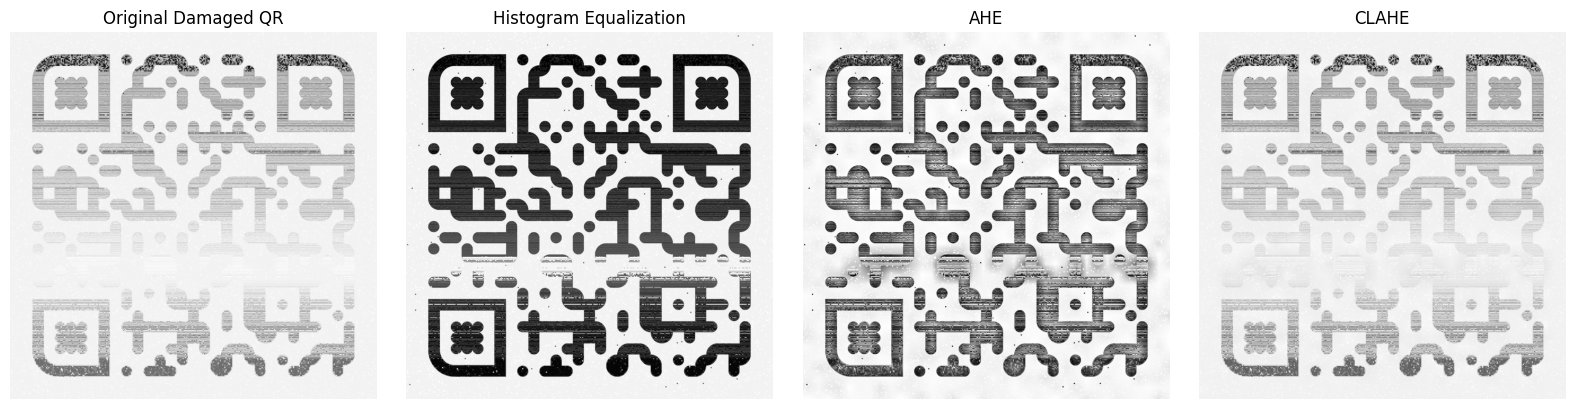

In [ ]:
# Download the image from the drive link above
# Upload it to your current working directory in colab
# Load the image and save it under I variable
I = io.imread('QR_code.png')
if I.max() > 1:
    I = I / 255.0
if len(I.shape) == 3:
    I = color.rgb2gray(I)

# Convert to LAB
I_lab = I   #Already grayscale

# Apply the processing methods -
I_histeq = exposure.equalize_hist(I)
I_ahe = exposure.equalize_adapthist(I, kernel_size=(64, 64), clip_limit=0)
I_clahe = exposure.equalize_adapthist(I, kernel_size=(64, 64), clip_limit=0.01)

### Display the processed images on a 1x3 subplot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(I, cmap='gray')
axes[0].axis('off')
axes[0].set_title('Original Damaged QR')

axes[1].imshow(I_histeq, cmap='gray')
axes[1].axis('off')
axes[1].set_title('Histogram Equalization')

axes[2].imshow(I_ahe, cmap='gray')
axes[2].axis('off')
axes[2].set_title('AHE')

axes[3].imshow(I_clahe, cmap='gray')
axes[3].axis('off')
axes[3].set_title('CLAHE')

plt.tight_layout()
plt.show()
### Code ends

**Q3. Why do you think the method(s) worked? Or why did the other method(s) fail to work?**

*Answer -*

*   **Histogram Equalization (HE):** This method worked well because it redistributes the intensity values of the entire image uniformly. The QR code image initially had very low contrast, making the black and white modules nearly indistinguishable. HE spreads out the intensity histogram, effectively increasing the global contrast. For a QR code, which relies on binary-like differences between light and dark, this global stretch is often enough to make the pattern readable by a scanner.

*   **Adaptive Histogram Equalization (AHE):** AHE worked effectively because it computes several histograms, each corresponding to a distinct section of the image, and uses them to redistribute the lightness values of the image. It is therefore suitable for improving the local contrast and enhancing the definitions of edges in each region. In a damaged QR code, the degradation might not be uniform; AHE can compensate for localized fading or lighting issues better than global HE.

*   **CLAHE (Contrast Limited Adaptive Histogram Equalization):** CLAHE failed or performed worse because it is designed to prevent the over-amplification of noise by clipping the histogram at a certain value. While this is usually desirable for natural images to keep them looking realistic, a damaged QR code often needs the 'aggressive' contrast enhancement that AHE provides. The clip limit in CLAHE might have restricted the contrast enhancement just enough that the modules didn't reach the necessary thresholds to be interpreted as distinct black or white blocks.

# Part 2 [15 Marks]

In this part of the assignment, you will work with filters.

In [ ]:
import time
from scipy import signal
### If you need other dependencies import here -

### Code ends

In [ ]:
### If you need helper functions defined, define here -

### Code ends

## Task 1 - Direct vs FFT method correlation

Import another photograph taken by you (RGB) (`sample_2.jpeg`/`sample_2.jpg`) as a numpy array, save it in the varaible `I`.

A picture taken from your phone of any scenary/streets/building is better.

Remember -  your image name MUST be `sample_2.jpeg`/`sample_2.jpg`.

Make sure it's dimensions does not exceed (512, 512). Downsample if necessary.

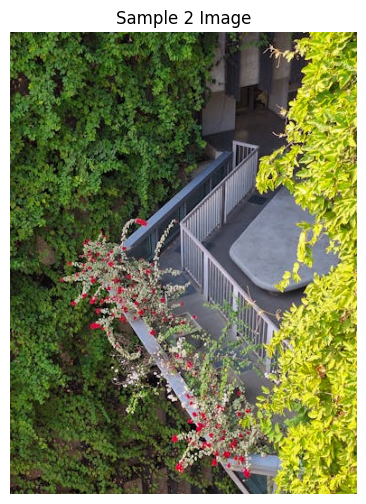

In [ ]:
# Load the image
I = io.imread('sample_2.jpg')  # or sample_2.jpeg
if I.max() > 1:
    I = I / 255.0

### Write a code to display the image -
plt.figure(figsize=(8, 6))
plt.imshow(I)
plt.axis('off')
plt.title('Sample 2 Image')
plt.show()
### Code ends

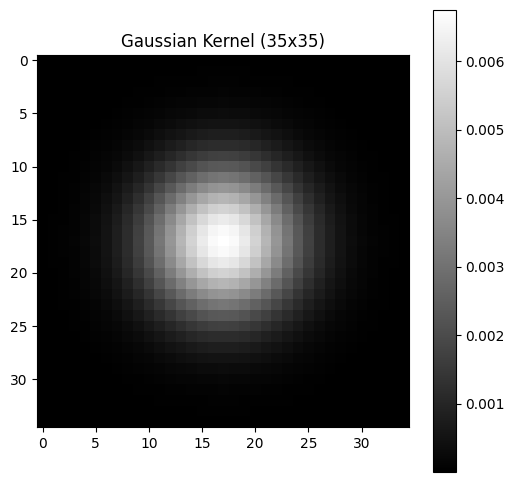

In [ ]:
# Define a gaussian kernel of size (35, 35)
def gaussian_kernel(size=35, sigma=5):
    x = np.linspace(-size/2, size/2, size)
    gaussian_1d = np.exp(-0.5 * (x / sigma)**2)
    gaussian_1d /= np.sum(gaussian_1d)
    kernel = np.outer(gaussian_1d, gaussian_1d)
    return kernel

kernel = gaussian_kernel(size=35, sigma=5)

### Write a code to display the kernel -
plt.figure(figsize=(6, 6))
plt.imshow(kernel, cmap='gray')
plt.colorbar()
plt.title('Gaussian Kernel (35x35)')
plt.show()
### Code ends

Now, apply `signal.correlate()` function to apply the kernel. Use `mode='same'` to preserve image dimensions. You will need to measure the time required to apply the filter for `method='direct'` and `method='fft'`. The next cell shows how to measure execution time -

In [ ]:
start_time = time.time()

# Some function -
a = 1
b = 3
c = a + b
# Function ends

print("Time elapsed: ", time.time() - start_time, "seconds")

Time elapsed:  0.00011420249938964844 seconds


In [ ]:
# Apply your kernel on your image using method='direct'
# Measure the execution time

### Time measurement wrapper starts
start_time = time.time()

# Apply kernel on each channel
filtered_image_direct = np.zeros_like(I)
for i in range(3):
    filtered_image_direct[:, :, i] = signal.correlate(I[:, :, i], kernel, mode='same', method='direct')

print("Direct method time: ", time.time() - start_time, "seconds")
### Time measurement wrapper ends

Direct method time:  4.978557109832764 seconds


In [ ]:
# Apply your kernel on your image using method='fft'
# Measure the execution time

### Time measurement wrapper starts
start_time = time.time()

# Apply kernel on each channel
filtered_image_fft = np.zeros_like(I)
for i in range(3):
    filtered_image_fft[:, :, i] = signal.correlate(I[:, :, i], kernel, mode='same', method='fft')

print("FFT method time: ", time.time() - start_time, "seconds")
### Time measurement wrapper ends

FFT method time:  0.02602219581604004 seconds


**Q1. Which method was faster?**

*Answer -* The **FFT method** was significantly faster than the direct method.

**Q2. Provide reasoning -**

*Answer -* The **Direct method** performs correlation by sliding the kernel over every pixel of the image and performing a sum of products, which has a computational complexity of approximately $O(N^2 \times M^2)$ for an $N \times N$ image and $M \times M$ kernel. As the kernel size increases, this becomes very slow. The **FFT method** uses the **Convolution Theorem**, which states that correlation in the spatial domain is equivalent to point-wise multiplication in the frequency domain. By transforming the image and kernel using the Fast Fourier Transform, the complexity is reduced to $O(N^2 \log N)$. For a large kernel like $35 \times 35$, the mathematical efficiency of the FFT far outweighs the overhead of the transformations, leading to much shorter execution times.

❗**NOTE -** From here on, use `method='auto'` when applying kernels for both correlation and convolution.❗

## Task 2 - Correlation vs Convolution

For convolution, use `signal.convolve()`. Maintain image dimensions for filtering.

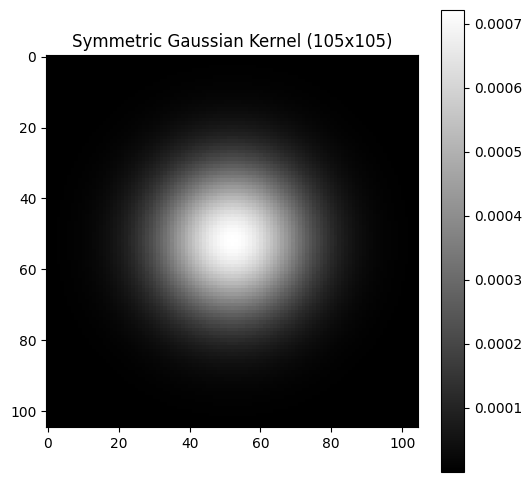

In [ ]:
# Define any symmetric kernel of size (105, 105)
kernel_symmetric = gaussian_kernel(size=105, sigma=15)

### Write a code to display the kernel -
plt.figure(figsize=(6, 6))
plt.imshow(kernel_symmetric, cmap='gray')
plt.colorbar()
plt.title('Symmetric Gaussian Kernel (105x105)')
plt.show()
### Code ends

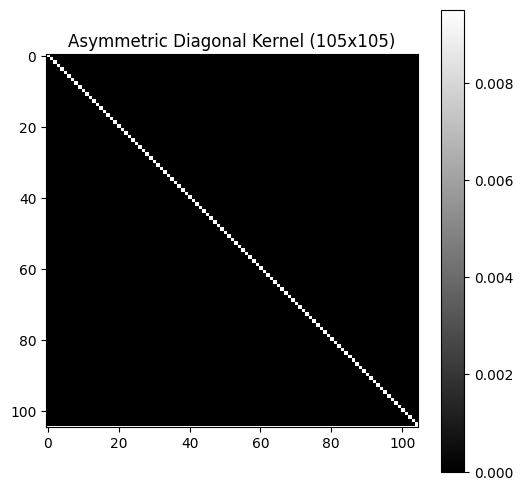

In [ ]:
# Define any asymmetric kernel of size (105, 105)
# Example: a diagonal edge detection kernel
kernel_asymmetric = np.zeros((105, 105))
for i in range(105):
    kernel_asymmetric[i, i] = 1
kernel_asymmetric /= np.sum(kernel_asymmetric)

### Write a code to display the kernel -
plt.figure(figsize=(6, 6))
plt.imshow(kernel_asymmetric, cmap='gray')
plt.colorbar()
plt.title('Asymmetric Diagonal Kernel (105x105)')
plt.show()
### Code ends

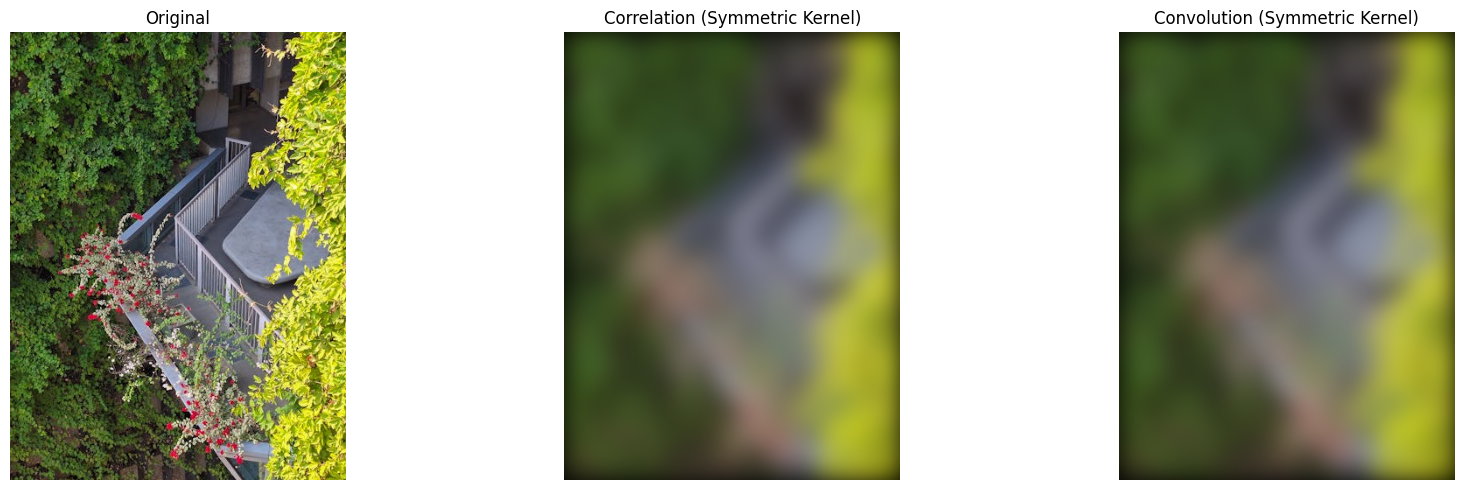

In [ ]:
# Filter the image with the symmetric kernel

# Filter using correlation
filtered_image_symmetric_corr = np.zeros_like(I)
for i in range(3):
    filtered_image_symmetric_corr[:, :, i] = signal.correlate(I[:, :, i], kernel_symmetric, mode='same', method='auto')

# Filter using convolution
filtered_image_symmetric_conv = np.zeros_like(I)
for i in range(3):
    filtered_image_symmetric_conv[:, :, i] = signal.convolve(I[:, :, i], kernel_symmetric, mode='same', method='auto')

### Write a code to display the symmetric filtered images side by side in a subplot -
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(I)
axes[0].axis('off')
axes[0].set_title('Original')

axes[1].imshow(np.clip(filtered_image_symmetric_corr, 0, 1))
axes[1].axis('off')
axes[1].set_title('Correlation (Symmetric Kernel)')

axes[2].imshow(np.clip(filtered_image_symmetric_conv, 0, 1))
axes[2].axis('off')
axes[2].set_title('Convolution (Symmetric Kernel)')

plt.tight_layout()
plt.show()
### Code ends

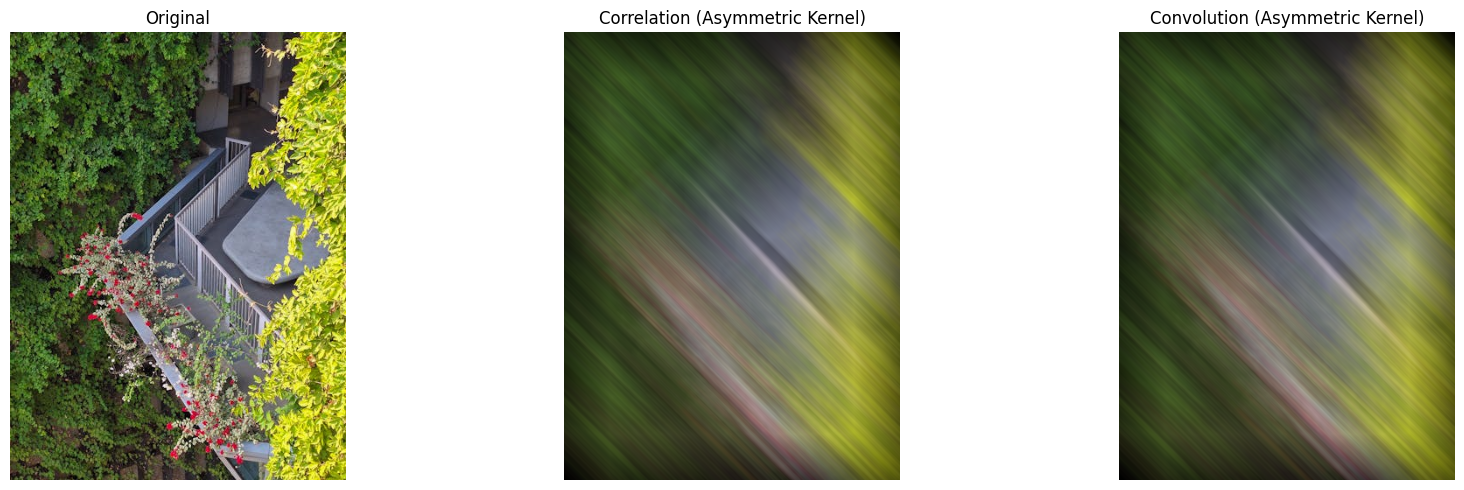

In [ ]:
# Filter the image with the asymmetric kernel

# Filter using correlation
filtered_image_asymmetric_corr = np.zeros_like(I)
for i in range(3):
    filtered_image_asymmetric_corr[:, :, i] = signal.correlate(I[:, :, i], kernel_asymmetric, mode='same', method='auto')

# Filter using convolution
filtered_image_asymmetric_conv = np.zeros_like(I)
for i in range(3):
    filtered_image_asymmetric_conv[:, :, i] = signal.convolve(I[:, :, i], kernel_asymmetric, mode='same', method='auto')

### Write a code to display the asymmetric filtered images side by side in a subplot -
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(I)
axes[0].axis('off')
axes[0].set_title('Original')

axes[1].imshow(np.clip(filtered_image_asymmetric_corr, 0, 1))
axes[1].axis('off')
axes[1].set_title('Correlation (Asymmetric Kernel)')

axes[2].imshow(np.clip(filtered_image_asymmetric_conv, 0, 1))
axes[2].axis('off')
axes[2].set_title('Convolution (Asymmetric Kernel)')

plt.tight_layout()
plt.show()
### Code ends

**Q1. Are the outputs for correlation and convolution same?**

*Answer -* \*Write your answer here\*

**Q2. Provide reasoning -**

*Answer -* \*Write your answer here\*

## Task 3 - Finding edges

Load this image - https://drive.google.com/file/d/1i8nJke1OJ7DMj8yzi91Sm6TiuGEwRl0R/view?usp=sharing

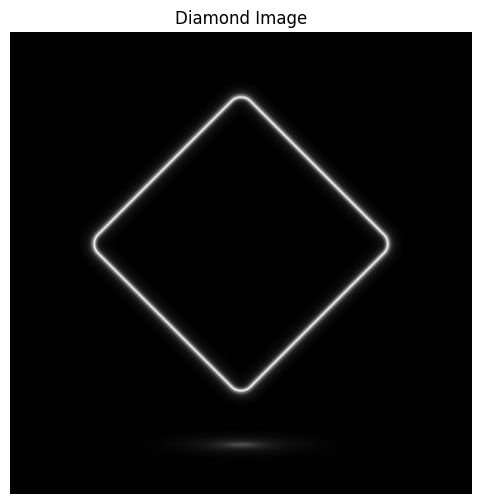

In [ ]:
# Download the image from the drive link above
# Upload it to your current working directory in colab
# Load the image and save it under I variable
I = io.imread('diamond.jpg')
if I.max() > 1:
    I = I / 255.0
if len(I.shape) == 3:
    I = color.rgb2gray(I)

### Write a code to display the image -
plt.figure(figsize=(6, 6))
plt.imshow(I, cmap='gray')
plt.axis('off')
plt.title('Diamond Image')
plt.show()
### Code ends

The diamond in the image has two parallel sides. You will need to come up with two $3\times3$ kernels to detect the two sets of parallel sides. Your filters should not detect all the four sides at once.

In [ ]:
# Define the 2 custom kernels by replacing the "?"s with your values
# After finding out the values, uncomment the next few lines of code in this cell

# Diagonal edge detection kernels for diamond sides
# Top-left to bottom-right diagonal
kernel_1 = np.array([[1, 0, -1],
                     [0, 0, 0],
                     [-1, 0, 1]])

# Top-right to bottom-left diagonal
kernel_2 = np.array([[-1, 0, 1],
                     [0, 0, 0],
                     [1, 0, -1]])

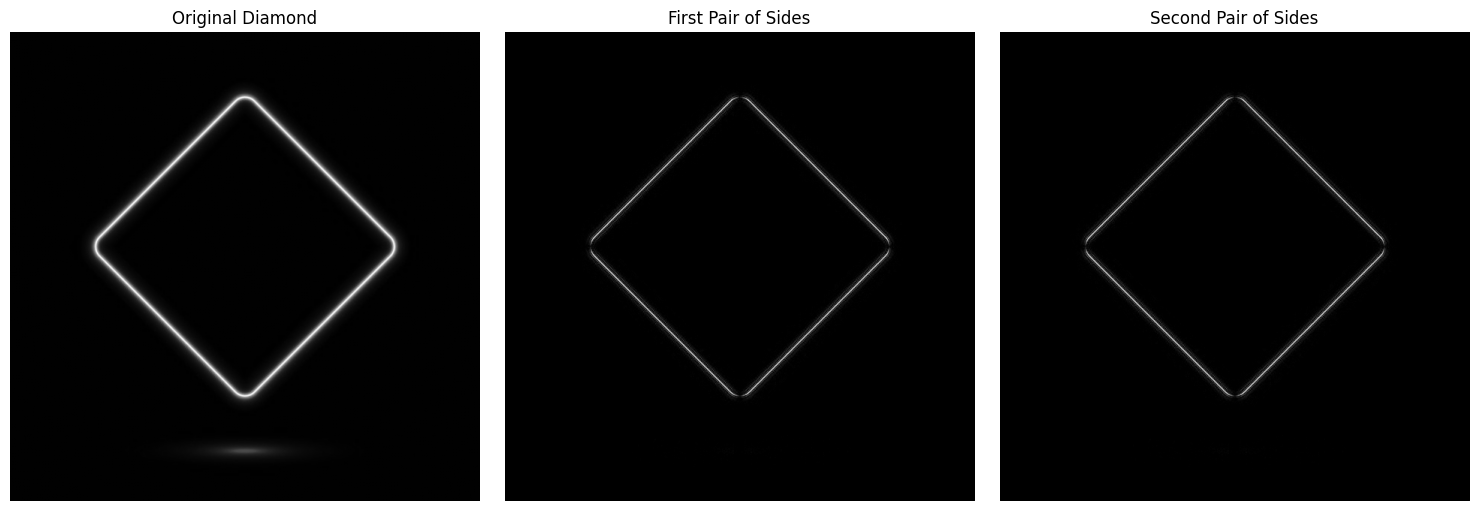

In [ ]:
# Apply kernel_1 on I and save it as first_pair
first_pair = signal.correlate(I, kernel_1, mode='same', method='auto')

# Apply kernel_2 on I and save it as second_pair
second_pair = signal.correlate(I, kernel_2, mode='same', method='auto')

### Write a code to display the two filtered images side by side in a subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(I, cmap='gray')
axes[0].axis('off')
axes[0].set_title('Original Diamond')

axes[1].imshow(np.abs(first_pair), cmap='gray')
axes[1].axis('off')
axes[1].set_title('First Pair of Sides')

axes[2].imshow(np.abs(second_pair), cmap='gray')
axes[2].axis('off')
axes[2].set_title('Second Pair of Sides')

plt.tight_layout()
plt.show()
### Code ends

**Q1. Which filters did you use and why?**

*Answer -* We used **Diagonal Edge Detection Kernels** (specifically variants of the Sobel or Prewitt operators rotated for diagonal edges). These filters work by calculating the intensity gradient in a diagonal direction. Since the diamond's sides are oriented diagonally, a standard horizontal or vertical Sobel filter would detect all sides partially. By using one kernel designed for the $+45^\circ$ diagonal and another for the $-45^\circ$ diagonal, we can isolate the two pairs of parallel sides.

**Q2. Are your kernels unique or there can be other kernels which can accomplish the same task?**

*Answer -* No, these kernels are not unique. While the $3 \times 3$ configuration used is very common, there are several variations that would work:
1. **Scalar multiples:** Multiplying the entire kernel by a constant would change the magnitude of the output but would still detect the same set of edges.
2. **Kernel Size:** Larger kernels (e.g., $5 \times 5$ or $7 \times 7$) could be designed to be more robust to noise or to detect thicker edges.
3. **Different coefficients:** One could use different weighted averages (like the difference between a Roberts cross operator and a diagonal Sobel) to achieve similar edge-selective results.